# Exploratory Data Analysis — Jakarta House Price Dataset

Notebook ini digunakan untuk eksplorasi awal dataset sebelum dibangun pipeline preprocessing & training di `src/`.


In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src import config, data_preprocessing as dp

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 1. Load & Inspeksi Data

In [2]:
df = dp.load_data()
dp.inspect_data(df)
df.head()


Shape dataset : (10000, 9)

Tipe data per kolom:
index              int64
price              int64
district             str
city                 str
bed_rooms          int64
bath_rooms         int64
carport            int64
land_area        float64
building_area    float64
dtype: object

Jumlah missing value per kolom:
index            0
price            0
district         0
city             0
bed_rooms        0
bath_rooms       0
carport          0
land_area        3
building_area    5
dtype: int64

Statistik deskriptif:
                  count unique              top  freq              mean  \
index         10,000.00    NaN              NaN   NaN          5,000.50   
price         10,000.00    NaN              NaN   NaN 10,040,290,040.00   
district          10000    253    Kelapa Gading   435               NaN   
city              10000      5  Jakarta Selatan  3379               NaN   
bed_rooms     10,000.00    NaN              NaN   NaN              4.25   
bath_rooms    10,000.0

,index,price,district,city,bed_rooms,bath_rooms,carport,land_area,building_area
0,1,5900000000,Citra Garden,Jakarta Barat,2,4,2,250.00,350.00
1,2,2700000000,Jelambar,Jakarta Barat,4,2,0,100.00,225.00
2,3,2200000000,Jelambar,Jakarta Barat,3,3,0,60.00,140.00
3,4,1900000000,Jelambar,Jakarta Barat,3,2,0,60.00,120.00
4,5,2100000000,Tanjung Duren,Jakarta Barat,4,3,0,56.00,108.00


## 2. Distribusi Target (price)

Price sangat skewed sehingga akan dilog-transform sebelum training.

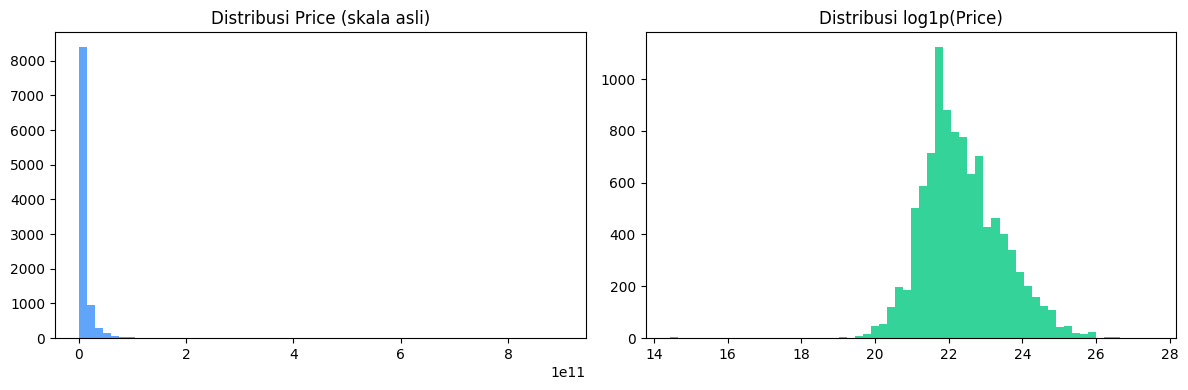

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["price"], bins=60, color="#60a5fa")
axes[0].set_title("Distribusi Price (skala asli)")

axes[1].hist(np.log1p(df["price"]), bins=60, color="#34d399")
axes[1].set_title("Distribusi log1p(Price)")
plt.tight_layout()
plt.show()


## 3. Distribusi Kategori (city & district)

In [4]:
print(df["city"].value_counts())
print()
print(f"Jumlah district unik: {df['district'].nunique()}")
df["district"].value_counts().head(15)


city
Jakarta Selatan    3379
Jakarta Barat      2622
Jakarta Utara      1739
Jakarta Timur      1690
Jakarta Pusat       570
Name: count, dtype: int64

Jumlah district unik: 253


district
Kelapa Gading          435
Pondok Indah           393
Pantai Indah Kapuk     364
Tebet                  341
Kebayoran Baru         340
Sunter                 340
Citra Garden           255
Jagakarsa              242
Cilandak               233
Kemang                 228
Lebak Bulus            217
Jakarta Garden City    195
Rawamangun             191
Jelambar               182
Duri Kepa              179
Name: count, dtype: int64

## 4. Korelasi Fitur Numerik dengan Price

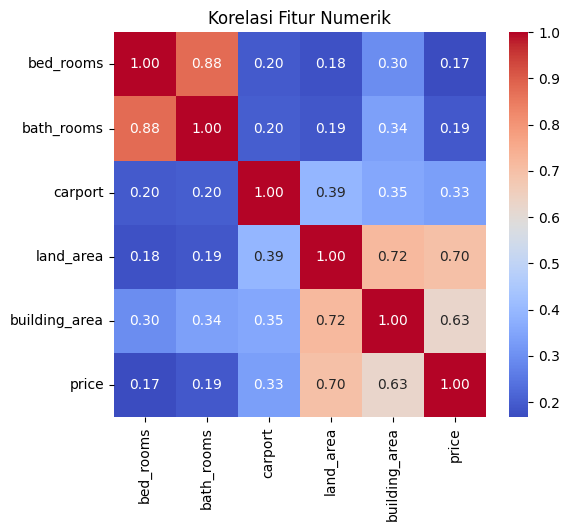

In [5]:
numeric_cols = config.NUMERIC_COLS + ["price"]
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
plt.title("Korelasi Fitur Numerik")
plt.show()


## 5. Cek Missing Value & Outlier

In [6]:
print(df.isnull().sum())
print()
print(df[config.NUMERIC_COLS].describe())


index            0
price            0
district         0
city             0
bed_rooms        0
bath_rooms       0
carport          0
land_area        3
building_area    5
dtype: int64

       bed_rooms  bath_rooms   carport  land_area  building_area
count  10,000.00   10,000.00 10,000.00   9,997.00       9,995.00
mean        4.25        3.52      1.58     296.61         319.96
std         3.18        2.90      1.74     502.92         357.68
min         0.00        0.00      0.00       1.00           1.00
25%         3.00        2.00      1.00     100.00         139.00
50%         4.00        3.00      1.00     177.00         230.00
75%         5.00        4.00      2.00     335.00         400.00
max        63.00       63.00     31.00  17,714.00      15,331.00


## 6. Kesimpulan Sementara

- `price` sangat skewed -> gunakan log1p transform untuk training.
- `district` memiliki 253 kategori unik -> gunakan frequency encoding, bukan one-hot.
- `city` hanya 5 kategori -> aman menggunakan one-hot encoding.
- Terdapat sedikit missing value pada `land_area` dan `building_area` -> imputasi median.
- Beberapa baris memiliki nilai ekstrem pada `price`, `bed_rooms`, `bath_rooms` -> capping/clipping diterapkan di pipeline (`src/data_preprocessing.py`).

Tahap selanjutnya (preprocessing, training, evaluasi) diimplementasikan secara modular di folder `src/`.
